# Word2Vec Hands-on Demo
This notebook demonstrates how to use Word2Vec from Gensim.

In [1]:
import gensim
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.3 MB/s eta 0:00:00


## Load and Preprocess Data

In [2]:
corpus = [
    "Word2Vec is a technique to learn word embeddings.",
    "Gensim provides an efficient implementation of Word2Vec.",
    "Word embeddings capture semantic relationships between words.",
    "You can use Word2Vec for text classification and sentiment analysis.",
    "Word2Vec supports CBOW and Skip-gram architectures.",
]
processed_corpus = [simple_preprocess(sentence) for sentence in corpus]

## Train Word2Vec Model

In [8]:
print(processed_corpus)
model = Word2Vec(
    sentences=processed_corpus, vector_size=100, window=5, min_count=1, workers=2
)
model.save("word2vec_demo.model")

[['word', 'vec', 'is', 'technique', 'to', 'learn', 'word', 'embeddings'], ['gensim', 'provides', 'an', 'efficient', 'implementation', 'of', 'word', 'vec'], ['word', 'embeddings', 'capture', 'semantic', 'relationships', 'between', 'words'], ['you', 'can', 'use', 'word', 'vec', 'for', 'text', 'classification', 'and', 'sentiment', 'analysis'], ['word', 'vec', 'supports', 'cbow', 'and', 'skip', 'gram', 'architectures']]


## Explore Word Vectors

In [14]:
word = "embeddings"
if word in model.wv:
    vector = model.wv[word]
    similar_words = model.wv.most_similar(word, topn=3)
    print(f"Vector for '{word}':\n", vector)
    print(f"\nTop 3 similar words to '{word}':\n", similar_words)
else:
    print(f"'{word}' not found in vocabulary.")

Vector for 'embeddings':
 [-8.2464442e-03  9.3026813e-03 -1.9631245e-04 -1.9676918e-03
  4.6063033e-03 -4.0981495e-03  2.7436351e-03  6.9419001e-03
  6.0697282e-03 -7.5149797e-03  9.3872361e-03  4.6727564e-03
  3.9704884e-03 -6.2457197e-03  8.4647294e-03 -2.1528366e-03
  8.8291978e-03 -5.3646206e-03 -8.1318840e-03  6.8276762e-03
  1.6725928e-03 -2.1990971e-03  9.5174480e-03  9.4973724e-03
 -9.7774863e-03  2.5060009e-03  6.1586769e-03  3.8748502e-03
  2.0230026e-03  4.3157287e-04  6.7356002e-04 -3.8216887e-03
 -7.1435929e-03 -2.0905396e-03  3.9252532e-03  8.8248886e-03
  9.2630740e-03 -5.9783258e-03 -9.4064083e-03  9.7683864e-03
  3.4324036e-03  5.1664817e-03  6.2862169e-03 -2.8043736e-03
  7.3271785e-03  2.8311601e-03  2.8708703e-03 -2.3814100e-03
 -3.1293682e-03 -2.3722362e-03  4.2806026e-03  7.7786564e-05
 -9.5864851e-03 -9.6710054e-03 -6.1519509e-03 -1.2743825e-04
  1.9977994e-03  9.4375098e-03  5.5866670e-03 -4.2919046e-03
  2.7894016e-04  4.9668350e-03  7.7013806e-03 -1.1450984e-0

In [17]:
import os

os.chdir("/content/drive/My Drive/Colab Notebooks/")

## Visualize Word Embeddings with PCA

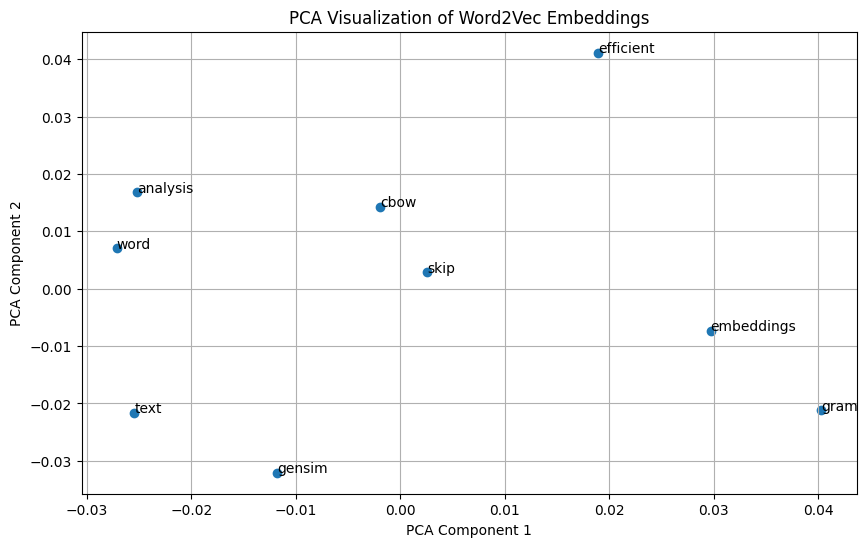

In [16]:
words_to_visualize = [
    "word",
    "gensim",
    "embeddings",
    "text",
    "analysis",
    "cbow",
    "skip",
    "gram",
    "efficient",
]
words_in_vocab = [w for w in words_to_visualize if w in model.wv]
vectors = [model.wv[w] for w in words_in_vocab]
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)
plt.figure(figsize=(10, 6))
plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(words_in_vocab):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.title("PCA Visualization of Word2Vec Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.savefig("word2vec_pca_visualization.png")
plt.show()